In [1]:
import torch
from diffusion.flows.prob_paths import GaussianCondProbPath
from diffusion.sampleables.sampleable_mnist import MNISTSampleable
from diffusion.backbones.res_unet_attn import BiTimeResUnet
from diffusion.generation.generator_flow_map import FlowMapGenerator
from diffusion.generation.generator import generate_samples
from diffusion.classifiers.encoder import compute_features
from diffusion.classifiers.encoder_mnist import MNISTClassifier
from diffusion.evaluation.evaluate import plot_metrics_per_class, evaluate_features
from diffusion.evaluation.visualize import (
    visualize_samples_per_class,
    visualize_tsne_per_class,
    visualize_umap_per_class,
)

In [2]:
if torch.cuda.is_available():
    device = torch.device("cuda")
elif torch.backends.mps.is_available():
    device = torch.device("mps")
else:
    device = torch.device("cpu")
print(device)

mps


In [3]:
sampeable = MNISTSampleable(train=False)
p_data_test = MNISTSampleable(train=False)

path = GaussianCondProbPath(p_data=sampeable, p_simple_shape=sampeable.shape).to(device)

backbone = BiTimeResUnet(
    in_channels=sampeable.shape[0],
    channel_dims=[16, 32, 64],
    use_attention=[False, False, True],
    num_classes=sampeable.num_classes,
    t_dim=64,
    y_dim=32,
    cond_dim=64,
).to(device)

encoder = MNISTClassifier(num_classes=sampeable.num_classes).to(device)

In [4]:
backbone_path = "./models/backbone_fmm_4.pt"
encoder_path = "./models/encoder.pt"

backbone.load_state_dict(torch.load(backbone_path))
encoder.load_state_dict(torch.load(encoder_path))

<All keys matched successfully>

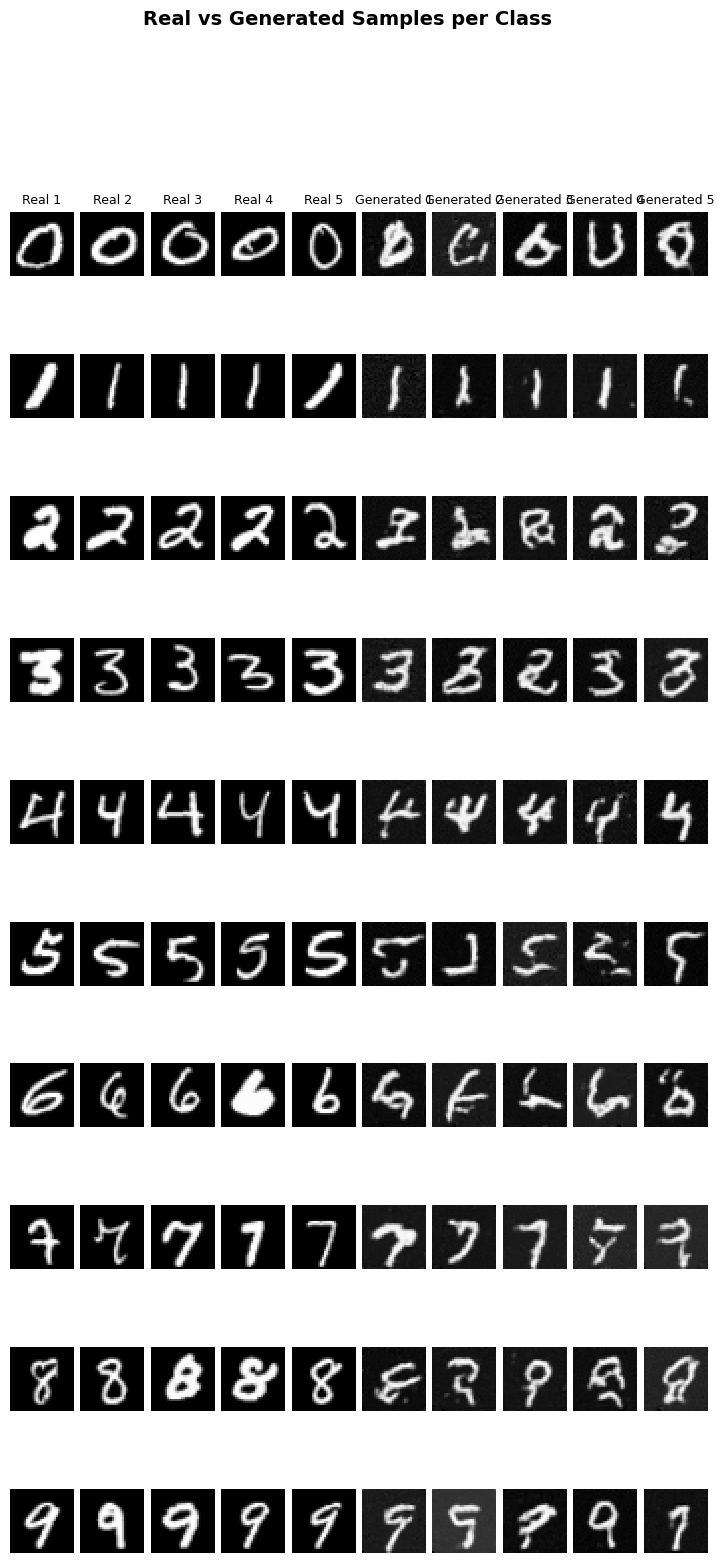

In [5]:
num_timesteps = 4
samples_per_class = 200
guidance_scale = None  # 3.0
seed = 42

flow_generator = FlowMapGenerator(
    path=path,
    backbone=backbone,  # type: ignore
    num_timesteps=num_timesteps,
    null_class=sampeable.num_classes,
    device=device,
)


synth_samples_flow, real_samples_flow = generate_samples(
    generator=flow_generator,
    p_data=p_data_test,
    samples_per_class=samples_per_class,
    num_classes=sampeable.num_classes,
    device=device,
    guidance_scale=guidance_scale,
)

visualize_samples_per_class(synth_samples_flow, real_samples_flow)

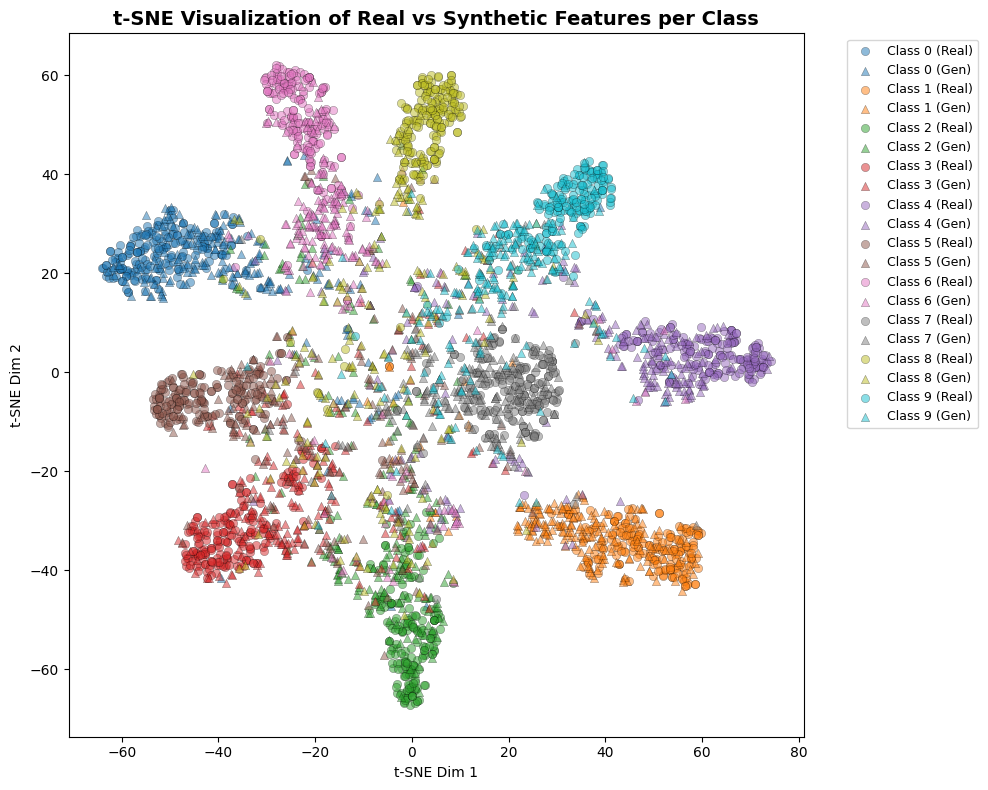

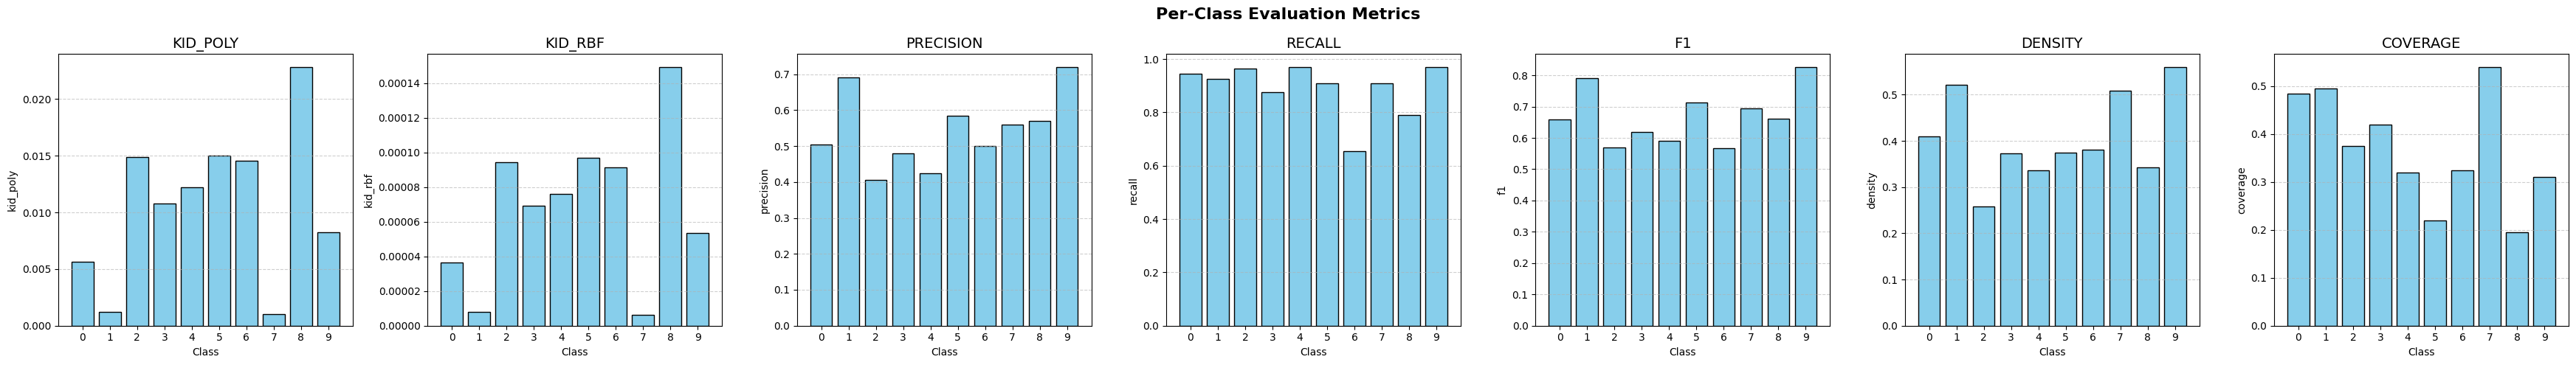

In [7]:
synth_features_flow, real_features_flow = compute_features(
    synth_samples_flow, real_samples_flow, encoder
)


visualize_tsne_per_class(synth_features_flow, real_features_flow)

# visualize_umap_per_class(synth_features_flow, real_features_flow)

metrics_per_class_flow = evaluate_features(synth_features_flow, real_features_flow)

plot_metrics_per_class(metrics_per_class_flow)